#Test

In [1]:
import numpy as np

In [4]:
# TASK: Load the California housing dataset from sklearn
# HINT: Use sklearn.datasets.fetch_california_housing(as_frame=True)
# HINT: Handle SSL errors by disabling certificate verification
# HINT: Extract the dataframe using data.frame
# HINT: Display the first few rows using .head()

import sklearn.datasets
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
sklearn.datasets.fetch_california_housing(as_frame=True)
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True)
df = df.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
# TASK: Check basic information about the dataset
# HINT: Use the .info() method to see data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# TASK: Check for missing values and get summary statistics
# HINT: Use .isna().sum() to count missing values per column
# HINT: Use .describe() for statistical summary
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
# TASK: Import matplotlib.pyplot for visualization
# HINT: You'll need this for plotting in later cells
import matplotlib.pyplot as plt


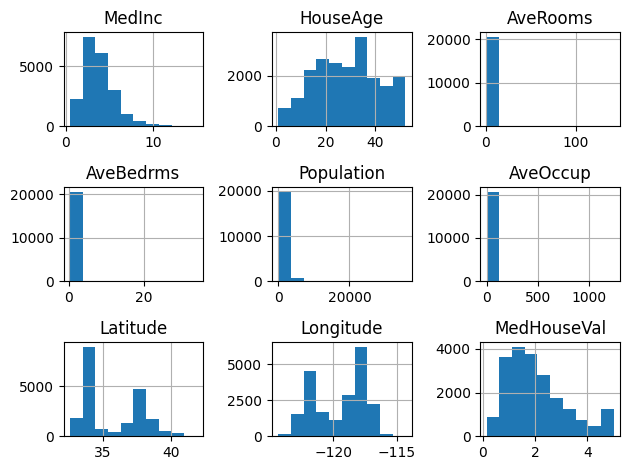

In [9]:
# TASK: Visualize the distributions of all features and the target variable
# HINT: Use df.hist() to create histograms for all columns
# HINT: Set figsize=(12,8) for a larger plot
# HINT: Use plt.tight_layout() to avoid overlapping labels
plt.figsize=(12,8)
df.hist()
plt.tight_layout()


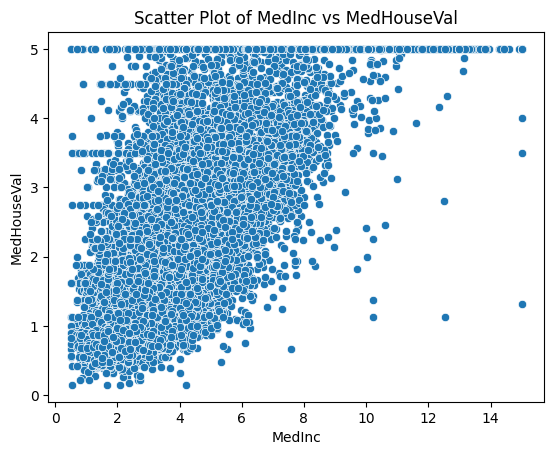

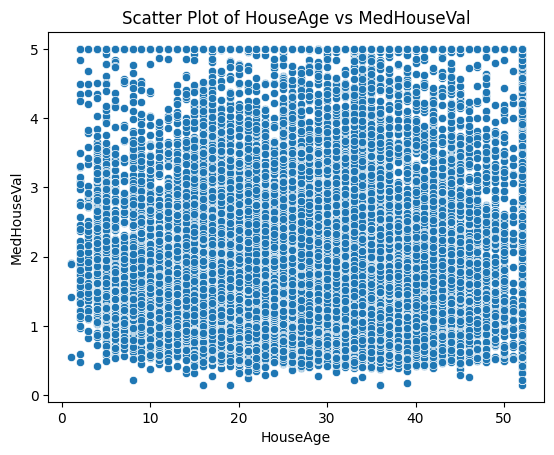

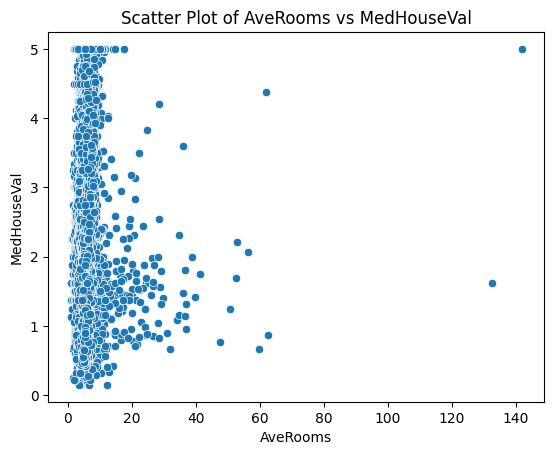

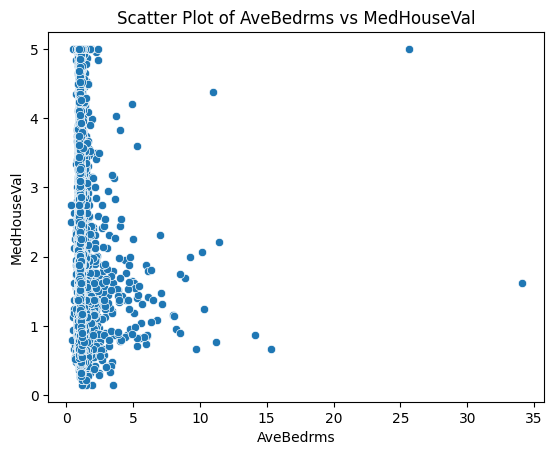

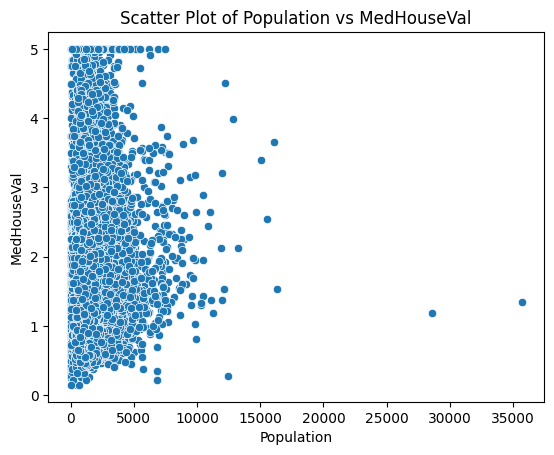

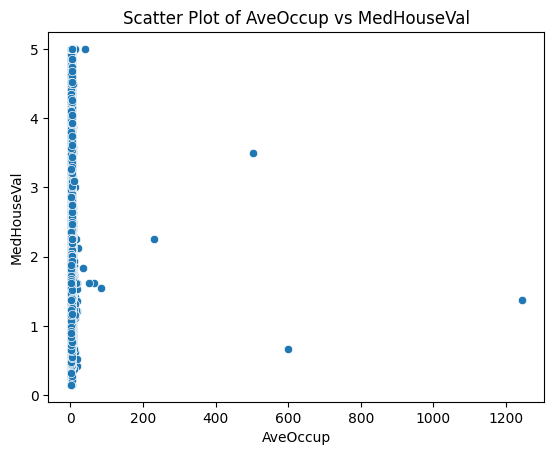

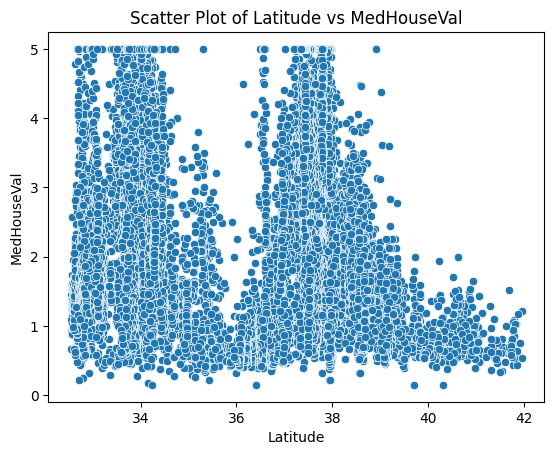

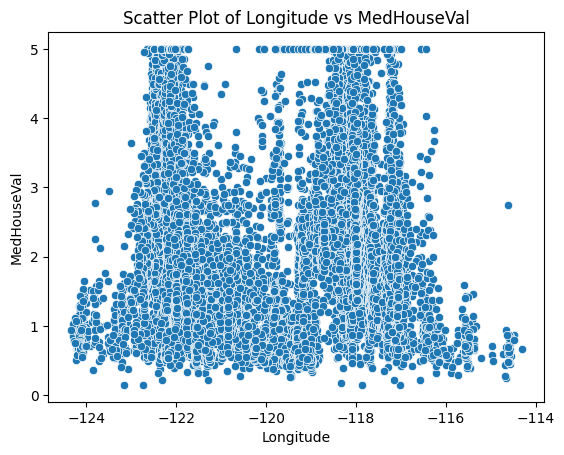

In [10]:
# TASK: Create scatter plots to check if features are linearly related to the target (MedHouseVal)
# HINT: Loop through df.columns[:-1] to get all features except the target
# HINT: Use sns.scatterplot(x=df[col], y=df['MedHouseVal'])
# HINT: Add a title for each plot using plt.title()
# HINT: Show each plot with plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
for col in df.columns[:-1]:
    plt.figsize=(6,4)
    sns.scatterplot(x=df[col], y=df['MedHouseVal'])
    plt.title(f'Scatter Plot of {col} vs MedHouseVal')
    plt.show()


How to decide if a linear model is OK?
Students should observe:

Some features (e.g., MedInc) show a clear linear-ish trend → good for linear regression.

Others (e.g., Latitude, Longitude) show non-linear patterns → linear model may struggle.

Distributions show skewness → may require transformations.

No missing values in this dataset → but we simulate missingness later.

Conclusion:  
A linear model is partially appropriate, but not perfect. Good for teaching.

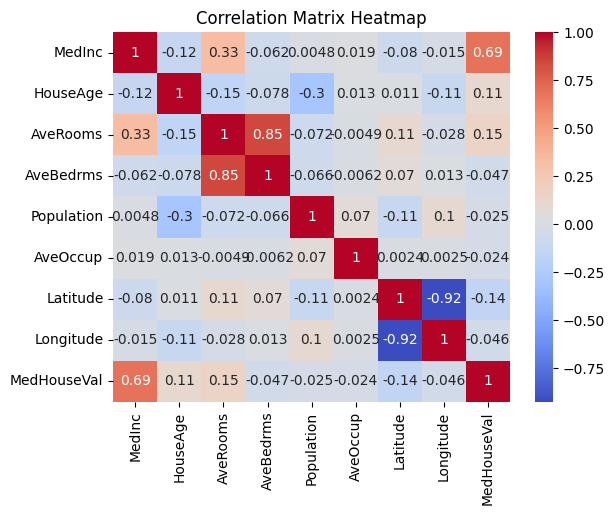

In [11]:
# TASK: Calculate and visualize the correlation matrix
# HINT: Use df.corr() to get the correlation matrix
# HINT: Use sns.heatmap() with annot=True to show values
# HINT: Use cmap='coolwarm' for color scheme

df_corr = df.corr()
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


In [12]:
# TASK: Find the top 3 features most correlated with the target variable
# HINT: First, create a correlation series: corr = df.corr()
# HINT: Get absolute values and sort in descending order
# HINT: Extract indices [1:4] (skip the first which is the target with itself)

corr_abs = df.corr().abs()
corr_target = corr_abs['MedHouseVal'].sort_values(ascending=False)
top_3_features = corr_target.index[1:4]
print(f"Top 3 features most correlated with MedHouseVal: {top_3_features}:{corr_target[top_3_features].values}")
print(top_3_features)

Top 3 features most correlated with MedHouseVal: Index(['MedInc', 'AveRooms', 'Latitude'], dtype='str'):[0.68807521 0.15194829 0.14416028]
Index(['MedInc', 'AveRooms', 'Latitude'], dtype='str')


Handling Missing Values & Outliers

In [13]:
# TASK: Simulate missing values by randomly removing 5% of 'MedInc' values
# HINT: Create a copy of the dataframe: df.copy()
# HINT: Use df_missing.sample(frac=0.05) to get 5% random samples
# HINT: Set those values to np.nan
# HINT: Check the result with .isna().sum()
df_missing = df.copy()
missing_values = df_missing['MedInc'].sample(frac=0.05)
df_missing.loc[missing_values.index, 'MedInc'] = np.nan
print(df_missing.isna().sum())


MedInc         1032
HouseAge          0
AveRooms          0
AveBedrms         0
Population        0
AveOccup          0
Latitude          0
Longitude         0
MedHouseVal       0
dtype: int64


In [14]:
# TASK: Impute missing values using the median strategy
# HINT: Use .fillna() with df_missing['MedInc'].median()
median_val = df_missing['MedInc'].median()
df_missing = df_missing.fillna({'MedInc': median_val})
print(median_val)
print(df_missing.isna().sum())


3.5341
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [15]:
# TASK: Detect outliers in 'MedHouseVal' using the IQR (Interquartile Range) method
# HINT: Calculate Q1 using .quantile(0.25)
# HINT: Calculate Q3 using .quantile(0.75)
# HINT: Calculate IQR = Q3 - Q1
# HINT: Define bounds: lower = Q1 - 1.5*IQR, upper = Q3 + 1.5*IQR
# HINT: Find outliers where values fall outside these bounds
# HINT: Print the count of outliers

Q1 = df['MedHouseVal'].quantile(0.25)
Q3 = df['MedHouseVal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['MedHouseVal'] < lower) | (df['MedHouseVal'] > upper)]
print(outliers.shape[0])

1071


In [16]:
# TASK: Remove outliers and create a cleaned dataset
# HINT: Filter the dataframe to keep only rows within the bounds
# HINT: Store result in df_no_outliers

df_no_outliers = df[(df['MedHouseVal'] >= lower) & (df['MedHouseVal'] <= upper)]
print(df_no_outliers.shape)
df_no_outliers.head()

(19569, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Task 1: Find the Problems

In [23]:
# TASK: Split the data into training and testing sets
# HINT: Import train_test_split from sklearn.model_selection
# HINT: Prepare X (features) by dropping 'MedHouseVal' column
# HINT: Prepare y (target) as the 'MedHouseVal' column
# HINT: Use train_test_split(X, y, test_size=0.2, random_state=42)
# HINT: This gives 80% training and 20% testing data
# HINT: Print the sizes of training and test sets

from sklearn.model_selection import train_test_split
X = df_no_outliers.drop('MedHouseVal', axis=1)
y = df_no_outliers['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 15655 samples
Test set size: 3914 samples


In [24]:
# TASK: Fit a Linear Regression model
# HINT: Import LinearRegression from sklearn.linear_model
# HINT: Create an instance: model = LinearRegression()
# HINT: Fit the model using model.fit(X_train, y_train)

import sklearn.linear_model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# TASK: Evaluate the model on test data
# HINT: Use model.predict(X_test) to get predictions
# HINT: Import r2_score and mean_absolute_error from sklearn.metrics
# HINT: Calculate R-squared: r2_score(y_test, y_pred)
# HINT: Calculate MAE: mean_absolute_error(y_test, y_pred)
# HINT: Print both metrics

from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")


R-squared: 0.6013
Mean Absolute Error: 0.4594


Learning Rate: 0.0001, Test MSE: 9579481596702926990798225408.0000
Learning Rate: 0.001, Test MSE: 269167474278258052656938352640.0000
Learning Rate: 0.01, Test MSE: 54353437326737553913927895613440.0000
Learning Rate: 0.1, Test MSE: 4233231989170646901337753003229184.0000


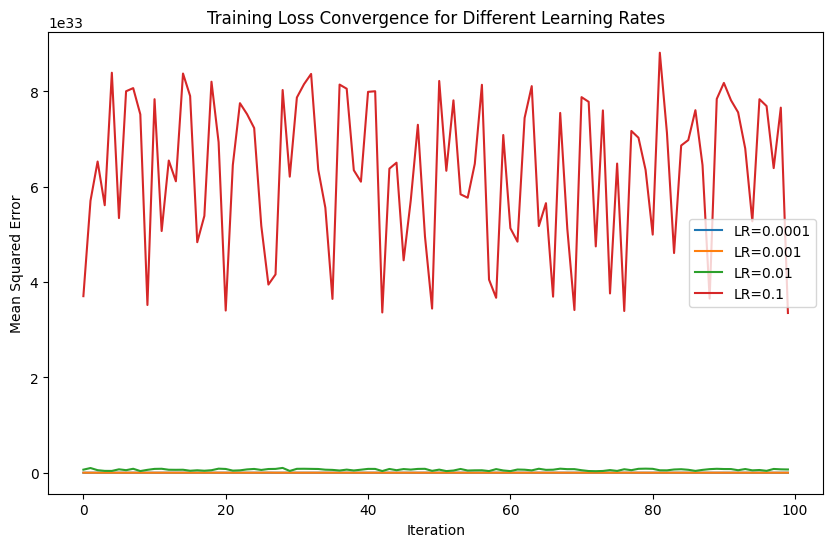

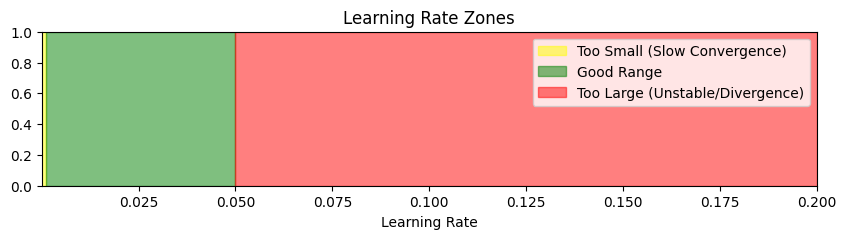

In [20]:
# TASK: Understand Gradient Descent and Learning Rate effects
#
# HINT: Gradient Descent is an optimization algorithm that:
# HINT:   - Starts with random weights
# HINT:   - Iteratively updates them by moving in the direction of steepest descent
# HINT:   - Learning rate controls the step size in each update
#
# TASK: Test different learning rates and compare convergence
# HINT: Define learning_rates = [0.0001, 0.001, 0.01, 0.1]
# HINT: Use SGDRegressor with learning_rate='constant' and eta0=lr parameter
# HINT: For each learning rate:
# HINT:   1. Fit the model with max_iter=1000
# HINT:   2. Track training losses over multiple iterations
# HINT:   3. Calculate test MSE using np.mean((predictions - y_test) ** 2)
# HINT:   4. Print the results
#

learning_rates = [0.0001, 0.001, 0.01, 0.1]
from sklearn.linear_model import SGDRegressor
for lr in learning_rates:
    sgd_model = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=1000, random_state=42)
    sgd_model.fit(X_train, y_train)
    y_pred_sgd = sgd_model.predict(X_test)
    mse = np.mean((y_pred_sgd - y_test) ** 2)
    print(f"Learning Rate: {lr}, Test MSE: {mse:.4f}")

    
# TASK: Visualize learning rate effects with two plots:
# HINT: Plot 1: Training loss convergence for each learning rate
# HINT:   - X-axis: iteration number
# HINT:   - Y-axis: Mean Squared Error
# HINT:   - Create multiple lines (one per learning rate)

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    sgd_model = SGDRegressor(learning_rate='constant', eta0=lr, random_state=42)

    losses = []

    for i in range(100):  # train little by little
        sgd_model.partial_fit(X_train, y_train)
        y_pred = sgd_model.predict(X_train)
        loss = ((y_train - y_pred) ** 2).mean()  # MSE
        losses.append(loss)

    plt.plot(losses, label=f'LR={lr}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss Convergence for Different Learning Rates')
plt.legend()
plt.show()   



#
# HINT: Plot 2: Learning rate zones (conceptual visualization)
# HINT:   - Use axvspan() to shade three zones:
# HINT:     * Yellow: 0.00001 to 0.001 (too small - slow convergence)
# HINT:     * Green: 0.001 to 0.05 (good range)
# HINT:     * Red: 0.05 to 0.2 (too large - unstable/divergence)
#
plt.figure(figsize=(10, 2))
plt.axvspan(0.00001, 0.001, color='yellow', alpha=0.5, label='Too Small (Slow Convergence)')
plt.axvspan(0.001, 0.05, color='green', alpha=0.5, label='Good Range')
plt.axvspan(0.05, 0.2, color='red', alpha=0.5, label='Too Large (Unstable/Divergence)')
plt.xlim(0.00001, 0.2)
plt.xlabel('Learning Rate')
plt.title('Learning Rate Zones')
plt.legend()
plt.show()
# TASK: Key Takeaways
# HINT: - Smaller learning rates converge slower but more reliably
# HINT: - Larger learning rates risk overshooting and instability
# HINT: - Optimal learning rate balances speed and stability
# HINT: - Common practice: start with 0.01 or 0.001 and tune based on validation